# Forest Plot Extraction — Eval

Reads `table_catalog.csv`, filters for `table_type=forest_plot` and `status=complete`, runs extraction on each entry, compares to ground truth, and prints accuracy (cell_accuracy + row_match).

In [39]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
from shared.client import client, DEFAULT_MODEL
from shared.pdf import render_pages
from shared.eval import compare_tables, print_accuracy_summary
from shared.crop import crop_image
from agents.forest_plot.extract import extract_forest_plots_from_page, stitch_forest_plot_results
from agents.router.classify import classify_page

In [40]:
MODEL = DEFAULT_MODEL

catalog = pd.read_csv("../table_catalog.csv")
catalog["status"] = catalog["status"].str.strip()
forest_entries = catalog[catalog["table_type"] == "forest_plot"].copy()
# Eval all diabetes forest plots (4 sub-figures on page 6)
eval_entries = forest_entries[forest_entries["paper_id"] == "diabetes_obesity_metabolism_2023"]
print(f"Forest plot entries to evaluate: {len(eval_entries)}")
eval_entries

Forest plot entries to evaluate: 4


,paper_id,page,figure_id,table_type,variation,description,ground_truth_path,cell_accuracy,row_match,notes,status
2,diabetes_obesity_metabolism_2023,6,fig3a,forest_plot,study_level_simple,Gla-300 vs Gla-100 risk ratio for hypoglycemia...,papers/Diabetes Obesity Metabolism - 2023 - Jo...,100.0%,12.0,NaN,complete
3,diabetes_obesity_metabolism_2023,6,fig3b,forest_plot,study_level_simple,Gla-300 vs Gla-100 risk ratio for hypoglycemia...,papers/Diabetes Obesity Metabolism - 2023 - Jo...,100.0%,12.0,bbox crop needed for consistent 100%,complete
4,diabetes_obesity_metabolism_2023,6,fig3c,forest_plot,study_level_simple,Gla-300 vs Gla-100 risk ratio for hypoglycemia...,papers/Diabetes Obesity Metabolism - 2023 - Jo...,NaN,NaN,NaN,complete
5,diabetes_obesity_metabolism_2023,6,fig3d,forest_plot,study_level_simple,Gla-300 vs Gla-100 risk ratio for hypoglycemia...,papers/Diabetes Obesity Metabolism - 2023 - Jo...,100.0%,9.0,NaN,not started


In [ ]:
results = []
crop_pairs = []  # (figure_id, page_image, extract_image, bbox_dict) for visualization
os.makedirs("../output", exist_ok=True)

for _, row in eval_entries.iterrows():
    paper_id = row["paper_id"]
    page = int(row["page"])
    figure_id = row["figure_id"]
    gt_path = os.path.join("..", row["ground_truth_path"])

    # Derive plot index from figure_id suffix: fig3a→0, fig3b→1, fig3c→2, etc.
    suffix = figure_id[-1] if figure_id[-1].isalpha() else "a"
    plot_index = ord(suffix) - ord("a")

    # Derive PDF path from ground_truth_path: papers/<folder>/ground_truth/... → papers/<folder>/paper.pdf
    paper_dir = os.path.dirname(os.path.dirname(gt_path))
    pdf_path = os.path.join(paper_dir, "paper.pdf")

    print(f"\n--- {paper_id} p{page} {figure_id} ({row['description']}) ---")

    # Render page
    images = render_pages(pdf_path, [page])
    page_image = images[page]

    # Step 1: Router classifies the page
    classification = classify_page(client, MODEL, page_image)
    forest_plot_entries = [t for t in classification.tables if t.type == "forest_plot"]
    print(f"  Router found {len(classification.tables)} table(s), {len(forest_plot_entries)} forest plot(s)")
    for entry in forest_plot_entries:
        print(f"    - {entry.label}: {entry.description}")

    if not forest_plot_entries:
        print("  No forest plots classified on this page!")
        continue

    # Use the matching router entry's instruction for the target figure
    router_index = min(plot_index, len(forest_plot_entries) - 1)
    router_entry = forest_plot_entries[router_index]
    instruction = router_entry.instruction
    print(f"  Using router entry {router_index} for {figure_id}: {router_entry.label}")

    # Step 2: Crop image to bounding box if available
    if router_entry.bbox is not None:
        bbox_dict = router_entry.bbox.model_dump()
        extract_image = crop_image(page_image, bbox_dict)
        print(f"  Cropped to bbox: {bbox_dict}")
    else:
        bbox_dict = None
        extract_image = page_image
        print("  No bbox — using full page image")

    crop_pairs.append((figure_id, page_image, extract_image, bbox_dict))

    # Step 3: Extract using instruction from router
    page_result = extract_forest_plots_from_page(client, MODEL, extract_image, instruction=instruction)
    page_results = {page: page_result}
    dfs = stitch_forest_plot_results(page_results)

    if not dfs:
        print("  No forest plots extracted!")
        continue

    # Save all extracted plots to CSV
    for i, (label, df_ext, ftr) in enumerate(dfs):
        out_path = f"../output/{paper_id}_p{page}_{figure_id}_plot{i}.csv"
        df_ext.to_csv(out_path, index=False)
        print(f"  Saved: {out_path}")

    # Compare first extracted plot to ground truth (instruction targets the specific figure)
    _, df_extracted, footer = dfs[0]
    print(f"  Comparing extracted plot 0 for {figure_id}")
    if footer:
        print(f"  Footer: {footer}")
    df_truth = pd.read_csv(gt_path)
    result = compare_tables(df_truth, df_extracted)
    result["paper_id"] = paper_id
    result["page"] = page
    result["figure_id"] = figure_id
    results.append(result)
    print_accuracy_summary(result)


--- diabetes_obesity_metabolism_2023 p6 fig3a (Gla-300 vs Gla-100 risk ratio for hypoglycemia (events/total)) ---
  Router found 4 table(s), 4 forest plot(s)
    - Figure 1 (A): Forest plot comparing Gla-300 and Gla-100 across various studies for mean difference in an unspecified outcome (A).
    - Figure 1 (B): Forest plot comparing Gla-300 and Gla-100 across various studies for mean difference in an unspecified outcome (B).
    - Figure 1 (C): Forest plot comparing Gla-300 and Gla-100 across various studies for mean difference in an unspecified outcome (C).
    - Figure 1 (D): Forest plot comparing Gla-300 and Gla-100 across various studies for mean difference in an unspecified outcome (D).
  Using router entry 0 for fig3a: Figure 1 (A)
  Cropped to bbox: {'x_min': 7.3, 'y_min': 6.5, 'x_max': 92.0, 'y_max': 28.6}


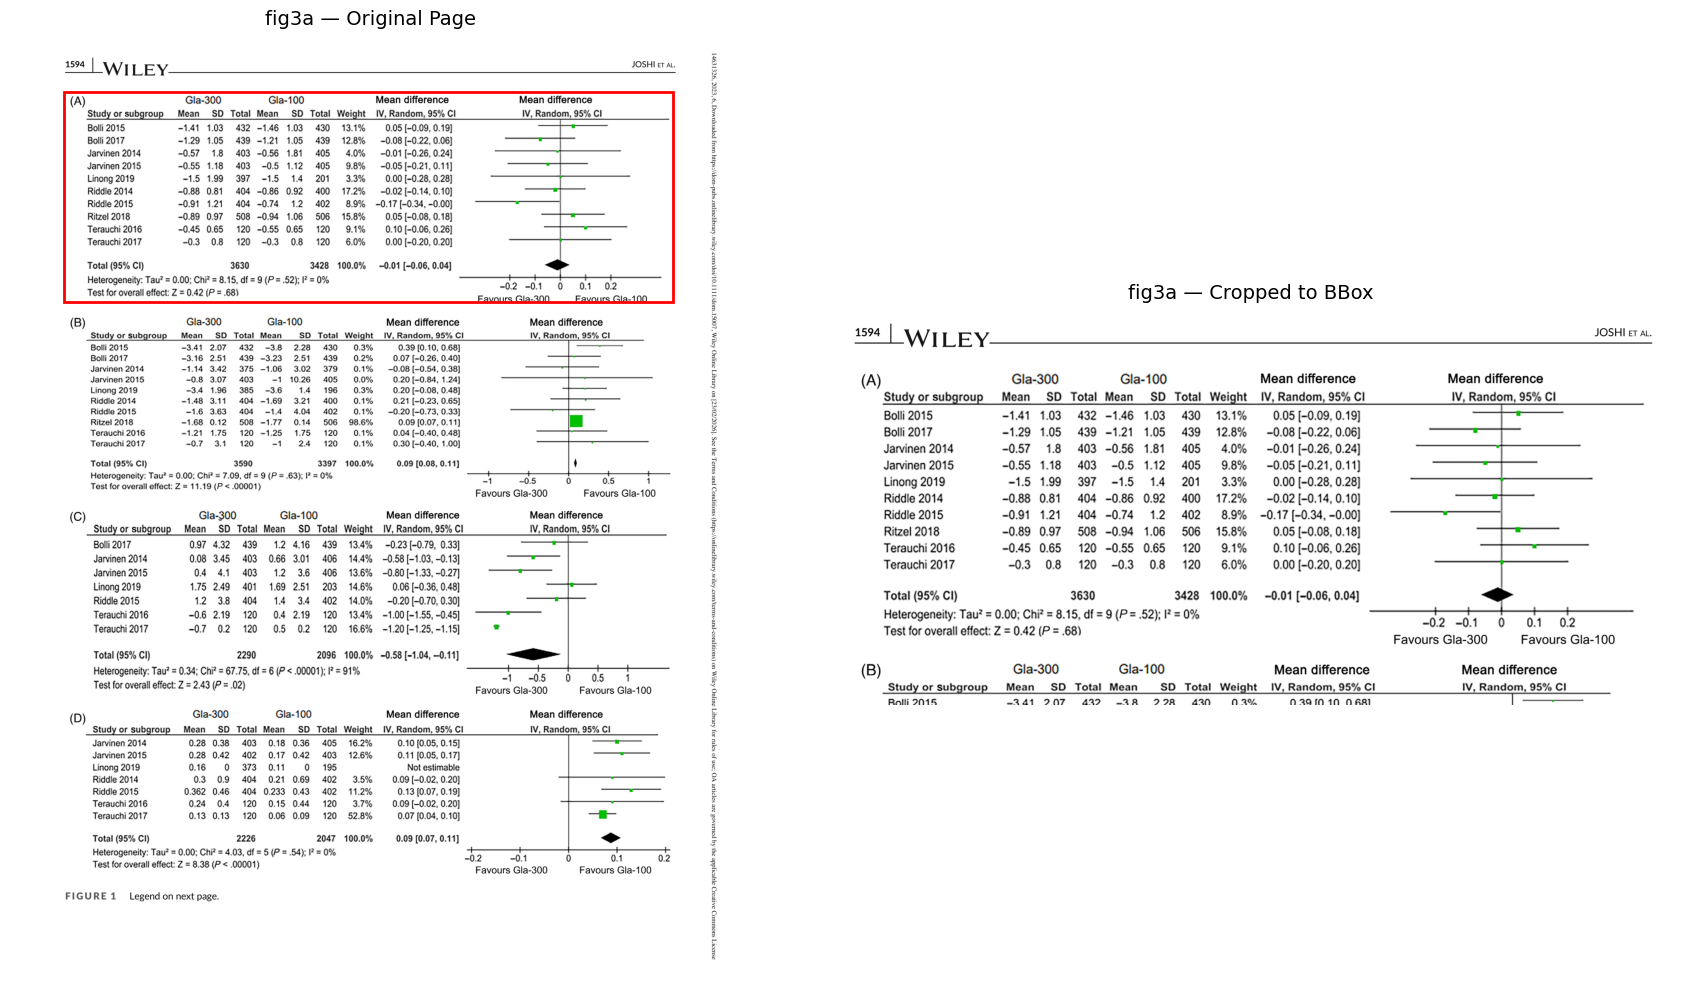

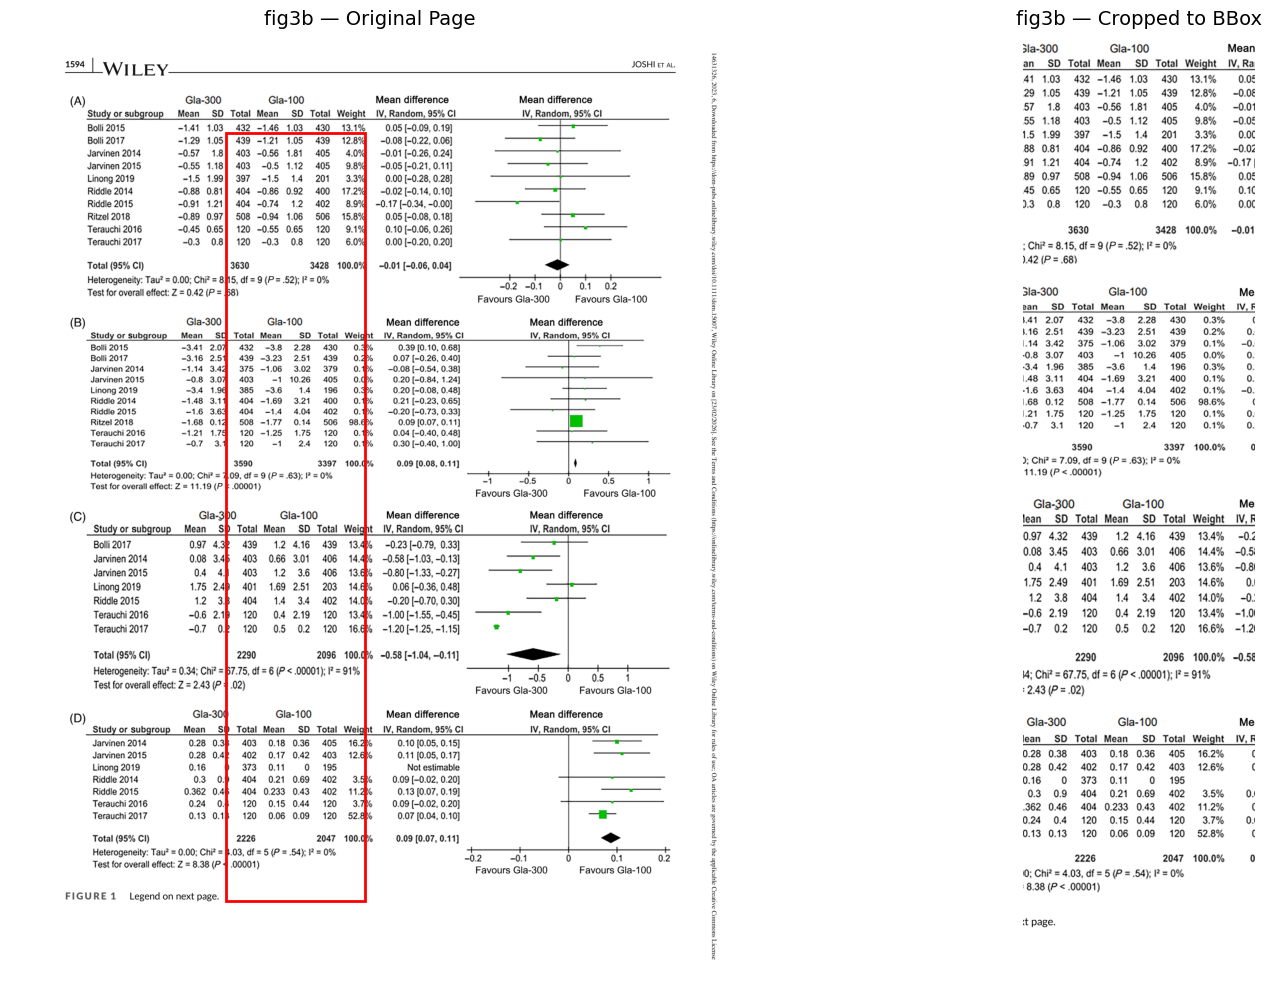

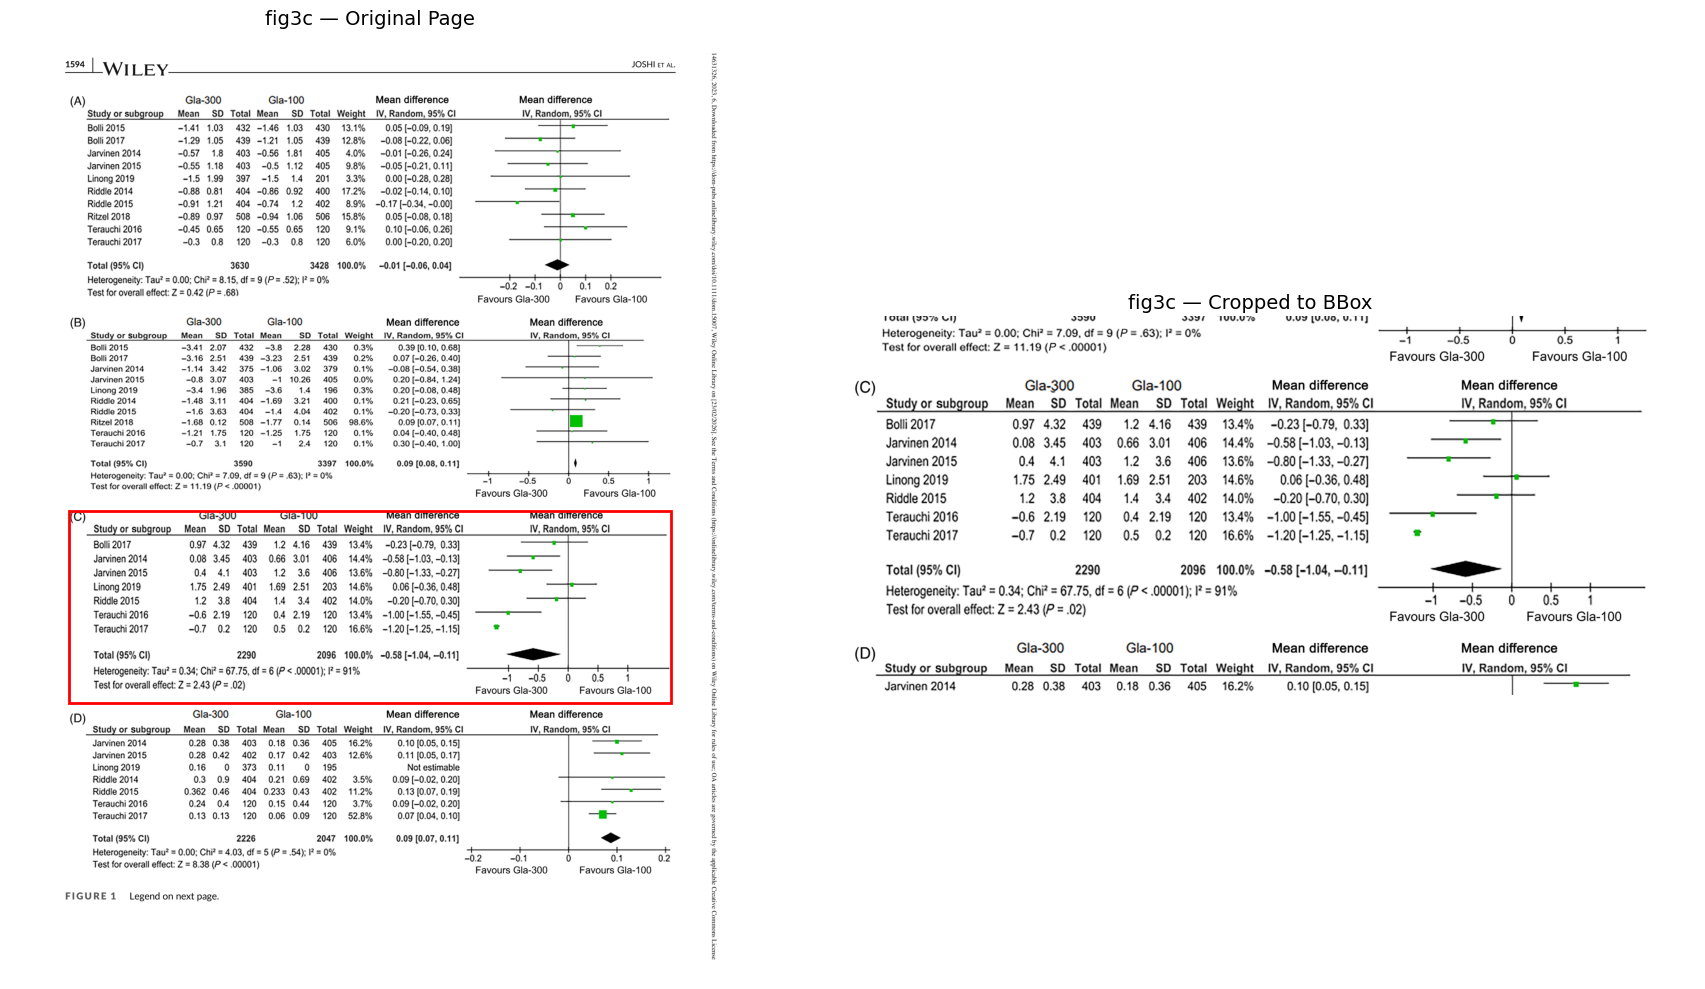

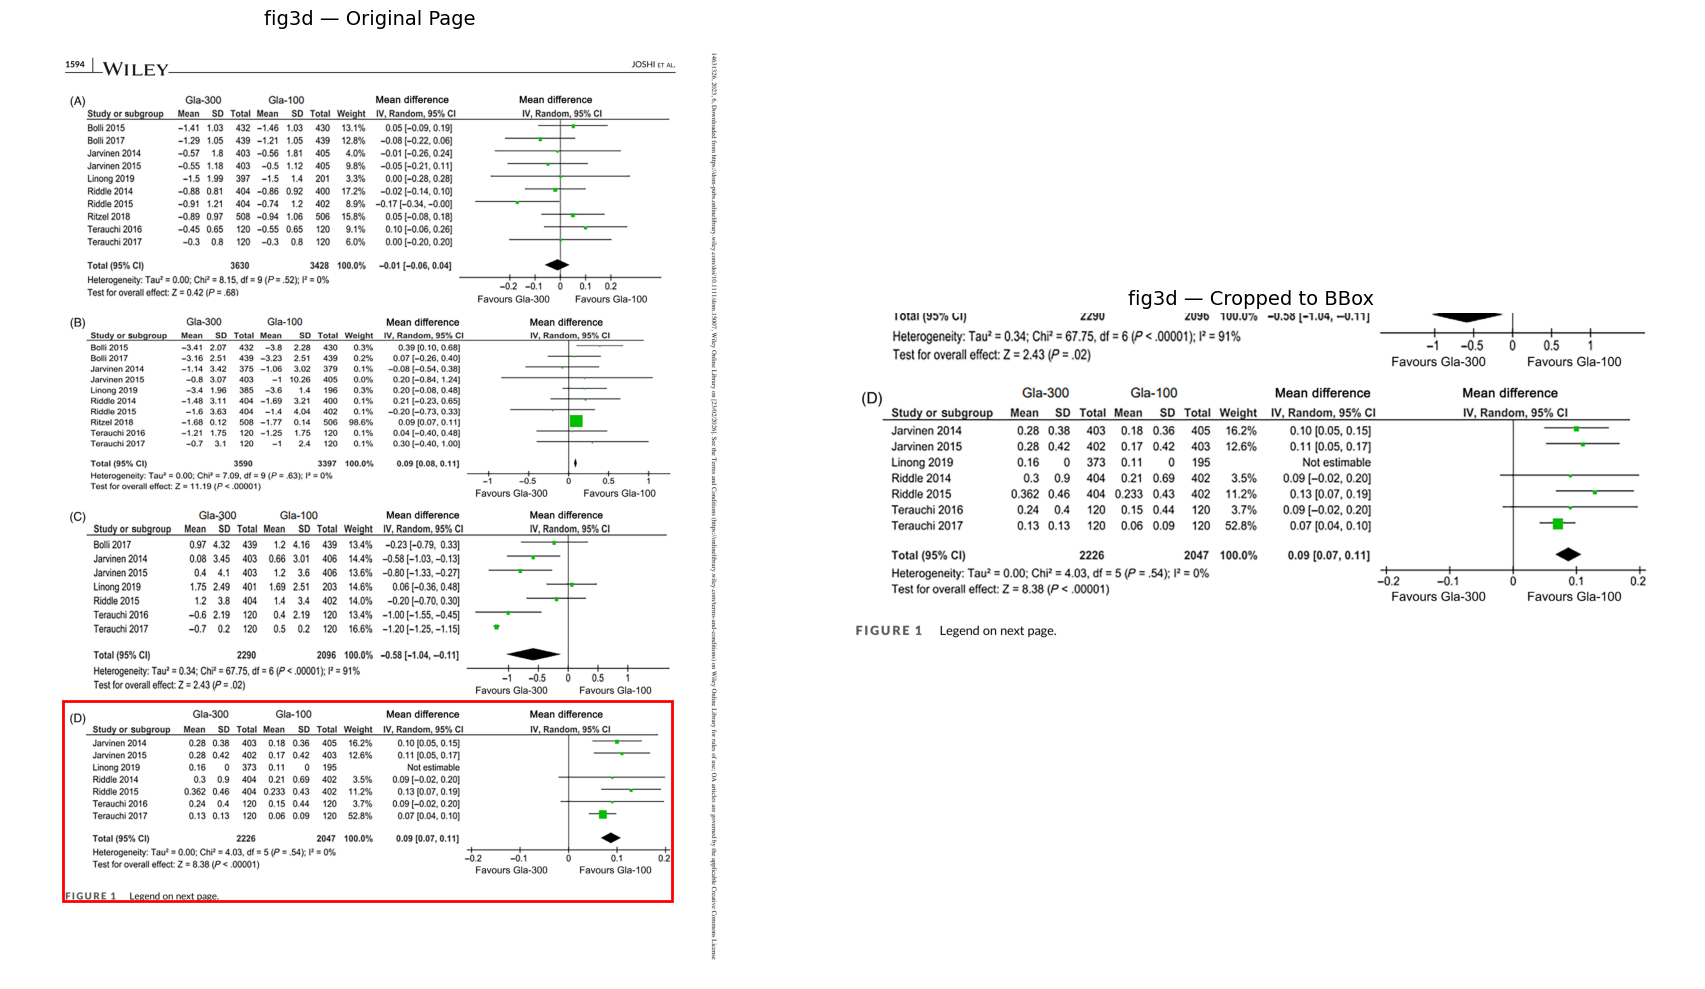

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

for figure_id, page_img, crop_img, bbox_dict in crop_pairs:
    fig, axes = plt.subplots(1, 2, figsize=(18, 10))

    # Left: original page with bbox rectangle overlay
    axes[0].imshow(page_img)
    axes[0].set_title(f"{figure_id} — Original Page", fontsize=14)
    if bbox_dict:
        w, h = page_img.size
        x = w * bbox_dict["x_min"] / 100
        y = h * bbox_dict["y_min"] / 100
        bw = w * (bbox_dict["x_max"] - bbox_dict["x_min"]) / 100
        bh = h * (bbox_dict["y_max"] - bbox_dict["y_min"]) / 100
        rect = patches.Rectangle((x, y), bw, bh, linewidth=2, edgecolor="red", facecolor="none")
        axes[0].add_patch(rect)
    axes[0].axis("off")

    # Right: cropped image
    axes[1].imshow(crop_img)
    axes[1].set_title(f"{figure_id} — Cropped to BBox", fontsize=14)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# Aggregate accuracy
if results:
    total_cells = sum(r["total_cells"] for r in results)
    correct_cells = sum(r["correct_cells"] for r in results)
    total_rows = sum(r["rows_compared"] for r in results)
    rows_correct = sum(r["rows_fully_correct"] for r in results)
    print(f"\n{'=' * 60}")
    print(f"AGGREGATE CELL ACCURACY: {correct_cells}/{total_cells} = {correct_cells/total_cells:.1%}")
    print(f"AGGREGATE ROW MATCH:     {rows_correct}/{total_rows} = {rows_correct/total_rows:.1%}")
    print(f"{'=' * 60}")
else:
    print("No entries evaluated.")


AGGREGATE CELL ACCURACY: 272/366 = 74.3%
AGGREGATE ROW MATCH:     30/42 = 71.4%
